## 10.8 图像增强
假如你要训练一个分辨猫和狗的模型，收集越多的图片训练的模型泛化性能越好。但是收集更多图片是有成本代价的。而图像增强技术是一个有效的快速获得更多训练样本的技术。

#### 10.8.1 图像增强是什么？
图像增强是指通过一系列变换方法，在保持图像语义（表达内容）不变的前提下，生成多样化的新图像数据。这些变换可以是几何的（如旋转、翻转）、颜色的（如亮度调整、颜色抖动），也可以是基于噪声、滤波或仿射变换等手段。

通过这些增强操作，我们可以从原始图像生成多个“不同但本质相同”的样本，显著增加数据多样性，提高模型鲁棒性。 图像增强可以分为以下几类：

- 几何变化
- 颜色变化
- 噪声与模糊
- 遮罩
- 其他技术

#### 10.8.2 几何变化
几何变化可以对图像进行以下操作： 旋转，一个图片旋转一定角度后，表达的语义是不变的。比如将一张猫的图片，旋转后，还是一个猫的图片。

In [7]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# 定义函数，展示变化前后的图片
def showIMG(img_path, transform):
      """
   Function to show data augmentation
   Param img_path: path of the image
   Param transform: data augmentation technique to apply
   """
      img = Image.open(img_path)
      fig, ax = plt.subplots(1, 2,figsize=(15,4))
      ax[0].set_title(f'Original image {img.size}')
      ax[0].imshow(img)
      img = transform(img)
      ax[1].set_title(f'Transformed image {img.size}')
      ax[1].imshow(img)
      plt.show()
    

##### 旋转

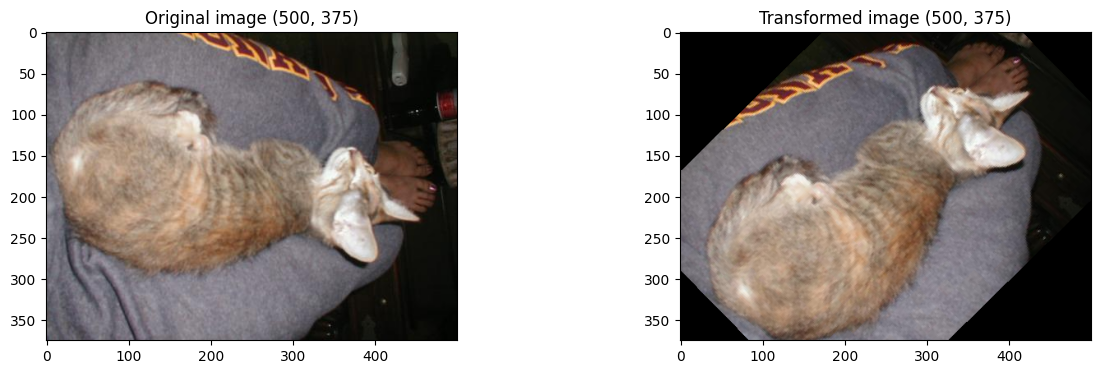

In [17]:
path = r"C:\Users\12702\Desktop\RethinkFun深度学习\第十章 - 卷积神经网络\data\PetImages\Cat\24.jpg"
rotation = transforms.RandomRotation(90) # 这里是在指定范围里随机旋转
# transform = transforms.RandomRotation((90, 90))  # 固定 90°
showIMG(path,rotation)

##### 翻转

- 水平翻转

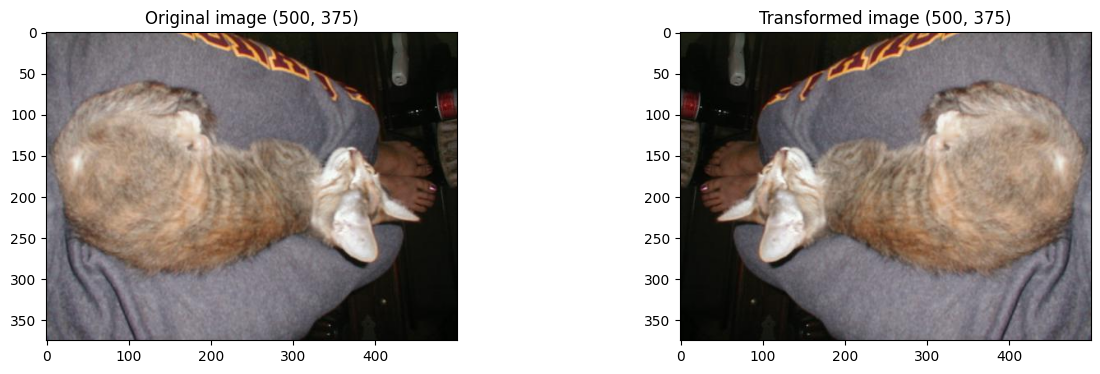

In [18]:
horizontal_flip = transforms.RandomHorizontalFlip(1.0) # p=1.0 表示总是翻转，p是翻转的概率值。
showIMG(path, horizontal_flip)

- 垂直翻转

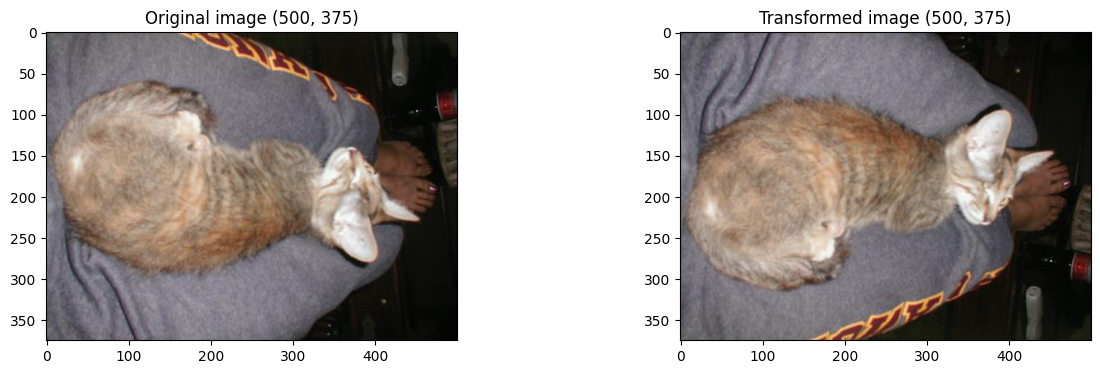

In [19]:
vertical_flip = transforms.RandomVerticalFlip(1.0)
showIMG(path, vertical_flip)

##### 裁剪
- 随机或者中心裁剪出图像区域

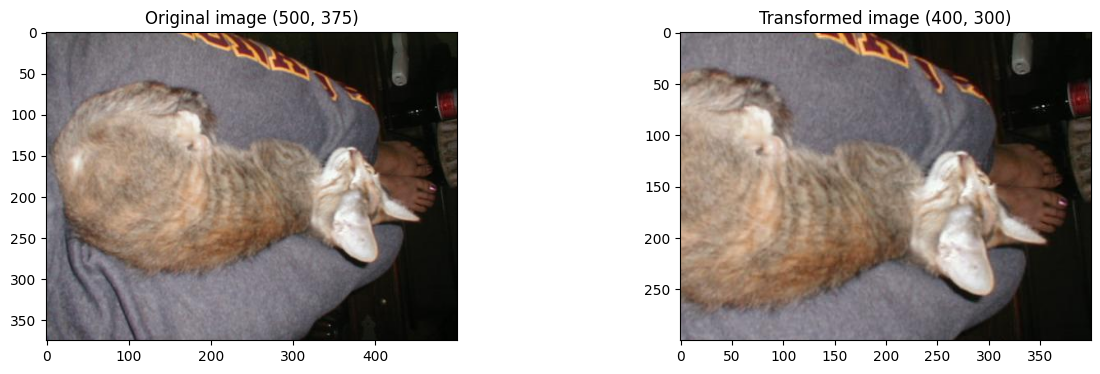

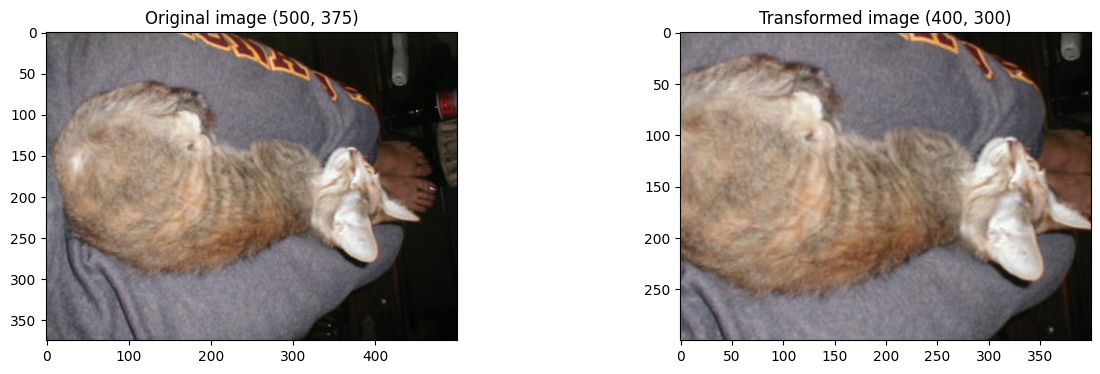

In [24]:
size = (int(375*0.8),int(500*0.8))
crop = transforms.RandomCrop(size) # 随机裁剪
showIMG(path,crop)
center_crop = transforms.CenterCrop(size)
showIMG(path, center_crop)

##### 透视变换
- 用于模拟图像拍摄时角度扭曲的效果

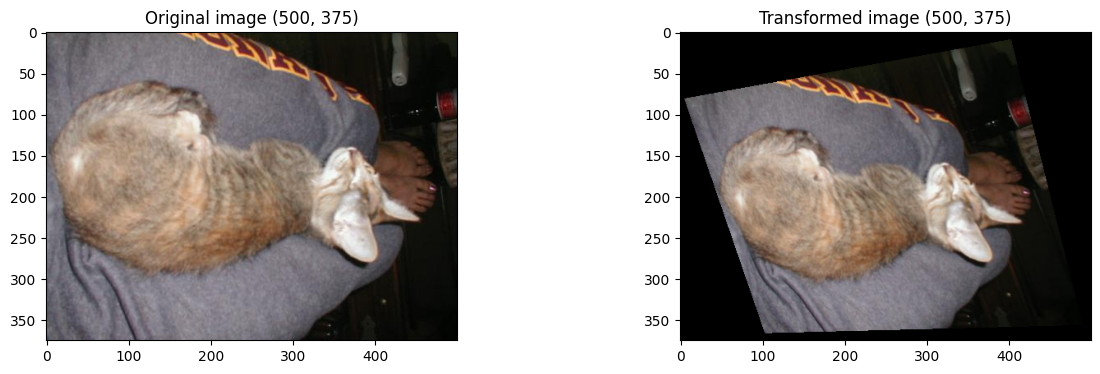

In [ ]:
perspective = transforms.RandomPerspective(
    distortion_scale=0.5, # 透视扭曲强度，范围通常是 [0, 1],越大越夸张
    p=1.0,  # 应用该增强的概率。
    # 变换过程中如何“插值”生成新像素
    # BILINEAR（双线性）通常在效果和速度上比较均衡，图像不会像最近邻那样锯齿明显。
    interpolation=transforms.InterpolationMode.BILINEAR 
    )
showIMG(path, perspective)

#### 10.8.3 颜色变化


具体参数设置：

- brightness 控制图像的亮暗程度。 设置为 x 时，相当于亮度因子从 [1 - x, 1 + x] 中随机选一个。 如 brightness=0.5，指的是亮度因子范围是 [0.5, 1.5]。

- contrast 控制图像的对比度（明暗之间的差异程度）。 同样是 [1 - x, 1 + x] 的范围。

- saturation 控制图像颜色的鲜艳程度。 [1 - x, 1 + x]

- hue 控制色调（颜色本质）在色环上旋转。 值范围应在 [-0.5, 0.5]。 hue=0.1， 色调会在 [-0.1, 0.1] 范围内扰动（即 ±10%）。

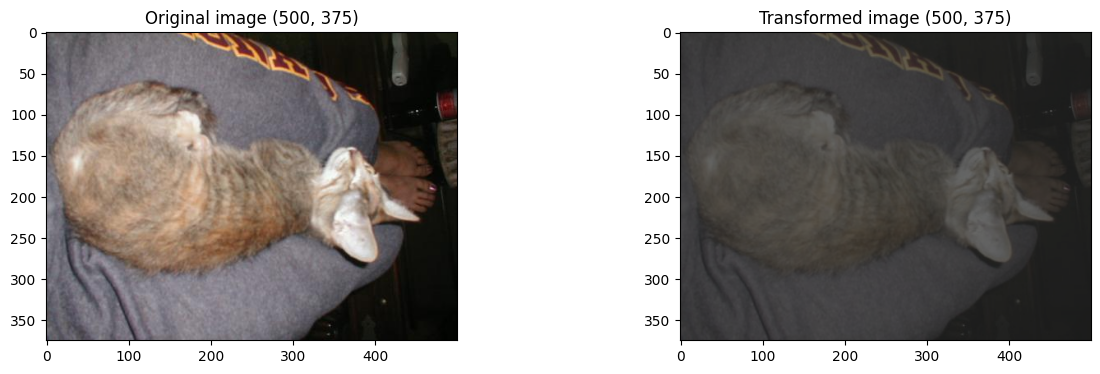

In [26]:
# 亮度、对比度、饱和度、色调
color_jitter = transforms.ColorJitter(
    brightness=0.5, 
    contrast=0.5, 
    saturation=0.5, 
    hue=0.1,
)
showIMG(path, color_jitter)

In [ ]:
# 以 50% 概率执行 ColorJitter
cj = transforms.RandomApply(
    [transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1)],
    p=0.5
)

#### 10.8.4 模糊

- ##### 高斯模糊
其中kernel_size指高斯模糊卷积核的大小（窗口大小）,它决定了模糊区域的范围，必须为奇数。设置越大，模糊效果越明显。sigma高斯模糊核的标准差范围（控制模糊程度的参数）,这里传入的是一个元组 (0.1, 3.0)，表示在这个范围内随机采样一个 sigma 值。sigma 越大，模糊越强；越小，模糊越轻。如果你传入单个数字，比如 sigma=1.0，那么模糊强度是固定的。

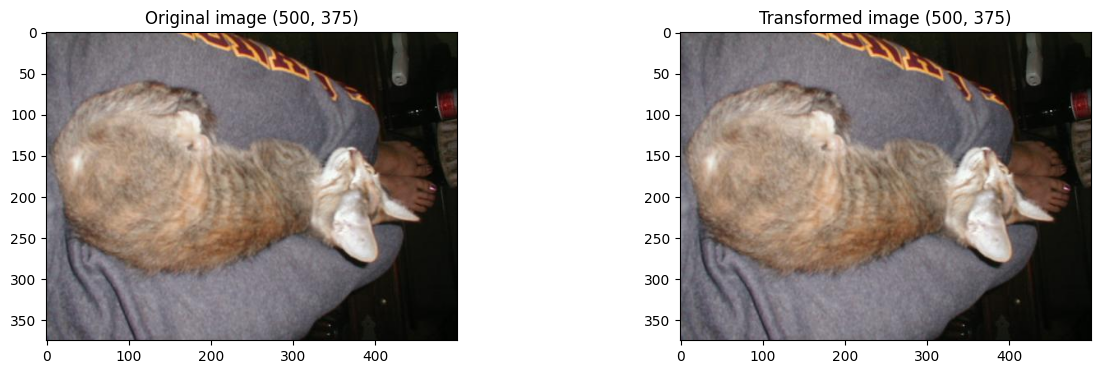

In [27]:
gaussian_blur = transforms.GaussianBlur(kernel_size=5, sigma=(0.1,3.0))
showIMG(path, gaussian_blur)

#### 10.8.5 遮罩
**遮罩(Cutout)** 遮罩的思想和Dropout的思想类似，它通过在训练图像上随机遮挡一个或多个连续的方形区域，从而让模型学会忽略局部信息，更关注整体上下文特征。这样，模型的鲁棒性得到提升，尤其在面对部分遮挡或图像缺失时表现更好。



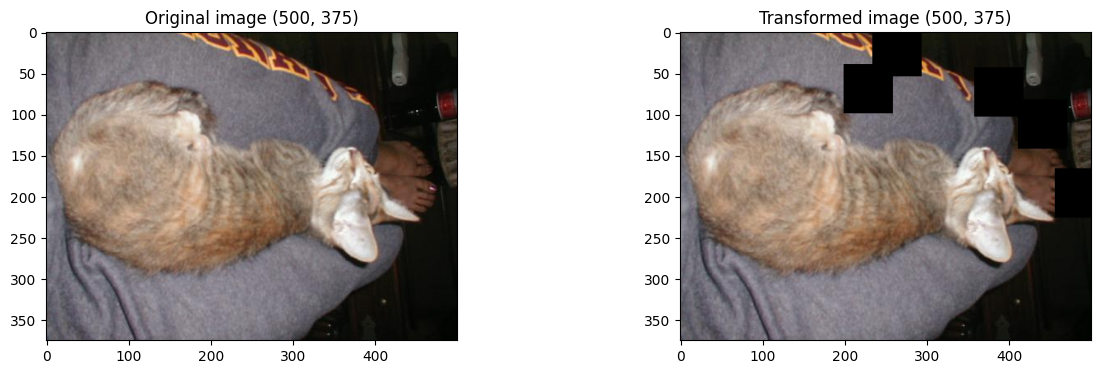

In [35]:
import numpy as np
import random

def CoutOut(img, mask_size=50, mask_num = 3):
    """
    对图像应用多个 Cutout 遮挡块

    参数:
    - image: PIL.Image 对象
    - mask_size: 每个遮挡块的大小（正方形边长）
    - num_masks: 遮挡块的数量
    """
    img_array = np.array(img).copy()
    h, w = img_array.shape[0], img_array.shape[1]

    for _ in range(mask_num):
        y = random.randint(0,h-1)
        x = random.randint(0,w-1)

        y1 = max(0, y-mask_size//2)
        y2 = min(h, y+mask_size//2)
        x1 = max(0, x-mask_size//2)
        x2 = min(w, x+mask_size//2)

        # 遮挡区域设置为黑色
        img_array[y1:y2, x1:x2, :] = 0

    return Image.fromarray(img_array)

cutout = lambda img :CoutOut(img, mask_size=60, mask_num=5)
showIMG(path, cutout)


#### 10.8.6 其他技术
通过上边的例子，可以发现图像增强是一个可以充分发挥你想象的技术。比如你可以给猫的图片里叠加一些经常和猫一起出现的物件，比如增加一个猫爬架。 你可以将猫的图片传入多模态大模型，让大模型生成一些类似的图片。